In [7]:
"""
Comparative Machine Learning Framework for Breast Cancer Diagnosis
Dataset: Wisconsin Breast Cancer Dataset
Author: [WAJID AYUB]
Date: December 2025
"""
# ============================================================================
# 1. IMPORT LIBRARIES
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)

# ML Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# For handling imbalanced data
from imblearn.over_sampling import SMOTE

# ============================================================================
# 2. LOAD DATASET
# ============================================================================
print("="*80)
print("BREAST CANCER DIAGNOSTIC PREDICTION SYSTEM")
print("="*80)

# Load the dataset
df = pd.read_csv('Breast Cancer Wisconsin (Diagnostic).csv')  # Change path if needed

print("\n[INFO] Dataset loaded successfully!")
print(f"Dataset Shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

BREAST CANCER DIAGNOSTIC PREDICTION SYSTEM

[INFO] Dataset loaded successfully!
Dataset Shape: (569, 33)
Number of samples: 569
Number of features: 33


In [8]:
# ============================================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Display first few rows
print("\n[1] First 5 rows of the dataset:")
print(df.head())

# Dataset information
print("\n[2] Dataset Information:")
print(df.info())

# Statistical summary
print("\n[3] Statistical Summary:")
print(df.describe())

# Check for missing values
print("\n[4] Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Check target variable distribution
print("\n[5] Target Variable Distribution:")
print(df['diagnosis'].value_counts())
print(f"\nClass Distribution:\n{df['diagnosis'].value_counts(normalize=True)*100}")



EXPLORATORY DATA ANALYSIS

[1] First 5 rows of the dataset:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

 

In [9]:
# ============================================================================
# 4. DATA PREPROCESSING
# ============================================================================
print("\n" + "="*80)
print("DATA PREPROCESSING")
print("="*80)

# Drop unnecessary columns
# 'id' column is not useful for prediction
# 'Unnamed: 32' is usually an empty column in this dataset
columns_to_drop = ['id']
if 'Unnamed: 32' in df.columns:
    columns_to_drop.append('Unnamed: 32')

df = df.drop(columns=columns_to_drop)
print(f"\n[1] Dropped columns: {columns_to_drop}")

# Handle missing values (if any)
if df.isnull().sum().sum() > 0:
    print("\n[2] Handling missing values...")
    df = df.fillna(df.mean(numeric_only=True))
    print("Missing values filled with mean values")
else:
    print("\n[2] No missing values found!")

# Encode target variable
print("\n[3] Encoding target variable...")
label_encoder = LabelEncoder()
df['diagnosis'] = label_encoder.fit_transform(df['diagnosis'])
print(f"Encoding: M (Malignant) = 1, B (Benign) = 0")

# Separate features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print(f"\n[4] Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Feature names
feature_names = X.columns.tolist()
print(f"\n[5] Number of features: {len(feature_names)}")


DATA PREPROCESSING

[1] Dropped columns: ['id', 'Unnamed: 32']

[2] No missing values found!

[3] Encoding target variable...
Encoding: M (Malignant) = 1, B (Benign) = 0

[4] Features shape: (569, 30)
Target shape: (569,)

[5] Number of features: 30



DATA VISUALIZATION

[INFO] EDA visualizations saved as 'eda_visualizations.png'


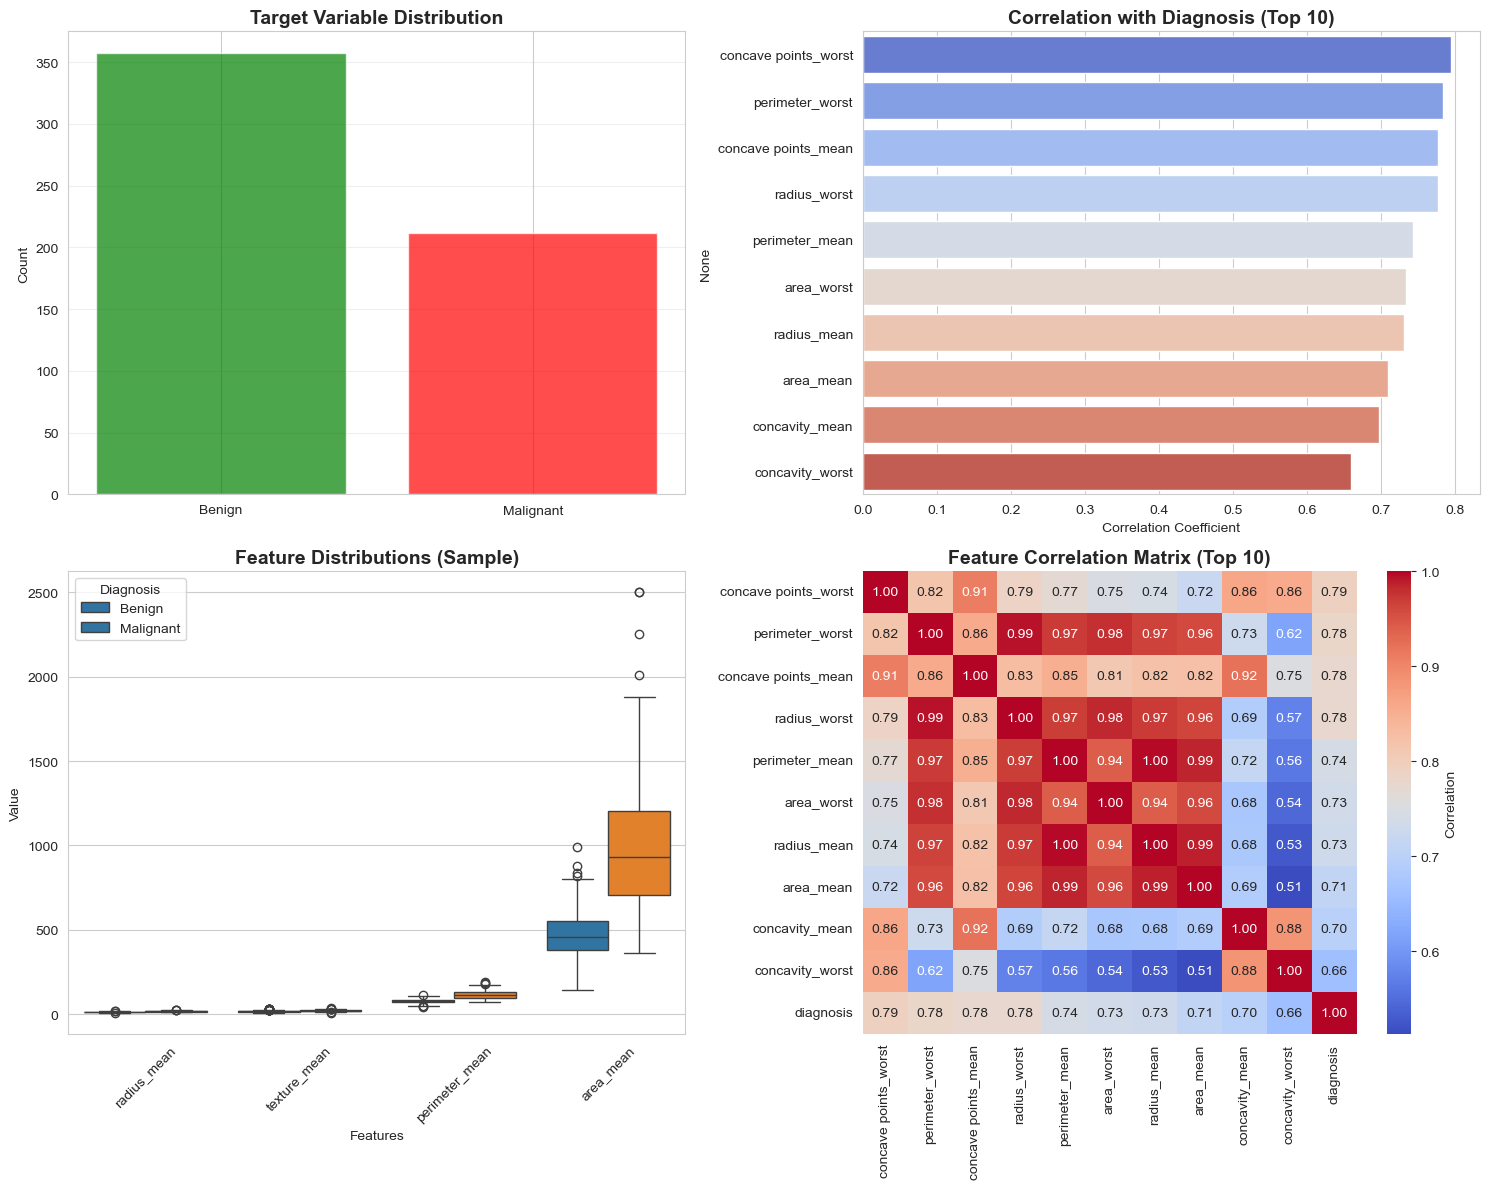

In [11]:
# ============================================================================
# 5. DATA VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("DATA VISUALIZATION")
print("="*80)

# Create figure for visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Target variable distribution
axes[0, 0].bar(['Benign', 'Malignant'], df['diagnosis'].value_counts().values, 
               color=['green', 'red'], alpha=0.7)
axes[0, 0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Correlation heatmap (top 10 features)
correlation_matrix = df.corr()
top_features = correlation_matrix['diagnosis'].abs().sort_values(ascending=False)[1:11].index
axes[0, 1].set_title('Correlation with Diagnosis (Top 10)', fontsize=14, fontweight='bold')
sns.barplot(x=correlation_matrix.loc[top_features, 'diagnosis'].values, 
            y=top_features, ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_xlabel('Correlation Coefficient')

# 3. Box plot for feature distributions
sample_features = X.columns[:4]
df_plot = df[list(sample_features) + ['diagnosis']].melt(id_vars='diagnosis')
sns.boxplot(data=df_plot, x='variable', y='value', hue='diagnosis', ax=axes[1, 0])
axes[1, 0].set_title('Feature Distributions (Sample)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Features')
axes[1, 0].set_ylabel('Value')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Diagnosis', labels=['Benign', 'Malignant'])

# 4. Feature correlation heatmap (full)
top_corr_features = correlation_matrix['diagnosis'].abs().sort_values(ascending=False)[1:11].index
corr_subset = df[list(top_corr_features) + ['diagnosis']].corr()
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[1, 1], cbar_kws={'label': 'Correlation'})
axes[1, 1].set_title('Feature Correlation Matrix (Top 10)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
print("\n[INFO] EDA visualizations saved as 'eda_visualizations.png'")
plt.show()


In [12]:
# ============================================================================
# 6. TRAIN-TEST SPLIT AND FEATURE SCALING
# ============================================================================
print("\n" + "="*80)
print("TRAIN-TEST SPLIT AND FEATURE SCALING")
print("="*80)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n[1] Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set positive class: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.2f}%)")
print(f"Testing set positive class: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n[2] Feature scaling applied using StandardScaler")
print("Features normalized to have mean=0 and std=1")

# Handle class imbalance using SMOTE
print("\n[3] Checking for class imbalance...")
print(f"Original training set distribution: {np.bincount(y_train)}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE: {np.bincount(y_train_balanced)}")
print("[INFO] SMOTE applied to balance the training data")


TRAIN-TEST SPLIT AND FEATURE SCALING

[1] Training set size: 455 samples
Testing set size: 114 samples
Training set positive class: 170 (37.36%)
Testing set positive class: 42 (36.84%)

[2] Feature scaling applied using StandardScaler
Features normalized to have mean=0 and std=1

[3] Checking for class imbalance...
Original training set distribution: [285 170]
After SMOTE: [285 285]
[INFO] SMOTE applied to balance the training data


  File "F:\AN\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [13]:
# ============================================================================
# 7. MODEL IMPLEMENTATION
# ============================================================================
print("\n" + "="*80)
print("MODEL IMPLEMENTATION")
print("="*80)

# Initialize models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'Neural Network': MLPClassifier(max_iter=1000, random_state=42)
}

# Train models and store results
results = {}
trained_models = {}

print("\n[INFO] Training models...")
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    trained_models[name] = model
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    if y_pred_proba is not None:
        auc_roc = roc_auc_score(y_test, y_pred_proba)
    else:
        auc_roc = None
    
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc_roc': auc_roc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"  ✓ {name} trained - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")



MODEL IMPLEMENTATION

[INFO] Training models...

Training Decision Tree...
  ✓ Decision Tree trained - Accuracy: 0.9123, F1-Score: 0.8810

Training Random Forest...
  ✓ Random Forest trained - Accuracy: 0.9737, F1-Score: 0.9630

Training SVM...
  ✓ SVM trained - Accuracy: 0.9737, F1-Score: 0.9639

Training Naive Bayes...
  ✓ Naive Bayes trained - Accuracy: 0.9386, F1-Score: 0.9114

Training KNN...
  ✓ KNN trained - Accuracy: 0.9649, F1-Score: 0.9512

Training Neural Network...
  ✓ Neural Network trained - Accuracy: 0.9649, F1-Score: 0.9500


In [15]:
# ============================================================================
# 8. HYPERPARAMETER TUNING
# ============================================================================
print("\n" + "="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

# Hyperparameter tuning for Random Forest
print("\n[1] Tuning Random Forest...")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=1,  # Changed from -1 to 1 to avoid multiprocessing issues
    verbose=1
)

rf_grid.fit(X_train_balanced, y_train_balanced)
print(f"\nBest Parameters for Random Forest: {rf_grid.best_params_}")
print(f"Best CV F1-Score: {rf_grid.best_score_:.4f}")

# Update Random Forest model with best parameters
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

results['Random Forest (Tuned)'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1_score': f1_score(y_test, y_pred_rf),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_rf),
    'y_pred': y_pred_rf,
    'y_pred_proba': y_pred_proba_rf
}

trained_models['Random Forest (Tuned)'] = best_rf

# Hyperparameter tuning for SVM
print("\n[2] Tuning SVM...")
svm_params = {
    'C': [1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 0.1]
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_params,
    cv=5,
    scoring='f1',
    n_jobs=1,  # Changed from -1 to 1 to avoid multiprocessing issues
    verbose=1
)

svm_grid.fit(X_train_balanced, y_train_balanced)
print(f"\nBest Parameters for SVM: {svm_grid.best_params_}")
print(f"Best CV F1-Score: {svm_grid.best_score_:.4f}")

# Update SVM model with best parameters
best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)
y_pred_proba_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

results['SVM (Tuned)'] = {
    'accuracy': accuracy_score(y_test, y_pred_svm),
    'precision': precision_score(y_test, y_pred_svm),
    'recall': recall_score(y_test, y_pred_svm),
    'f1_score': f1_score(y_test, y_pred_svm),
    'auc_roc': roc_auc_score(y_test, y_pred_proba_svm),
    'y_pred': y_pred_svm,
    'y_pred_proba': y_pred_proba_svm
}

trained_models['SVM (Tuned)'] = best_svm


HYPERPARAMETER TUNING

[1] Tuning Random Forest...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters for Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1-Score: 0.9757

[2] Tuning SVM...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1-Score: 0.9809



MODEL EVALUATION AND COMPARISON

[1] Performance Metrics for All Models:
                Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
          SVM (Tuned)  0.982456   1.000000 0.952381  0.975610 0.993386
                  SVM  0.973684   0.975610 0.952381  0.963855 0.995701
Random Forest (Tuned)  0.973684   1.000000 0.928571  0.962963 0.996362
        Random Forest  0.973684   1.000000 0.928571  0.962963 0.996362
                  KNN  0.964912   0.975000 0.928571  0.951220 0.977183
       Neural Network  0.964912   1.000000 0.904762  0.950000 0.994709
          Naive Bayes  0.938596   0.972973 0.857143  0.911392 0.991402
        Decision Tree  0.912281   0.880952 0.880952  0.880952 0.905754

[2] Best Performing Model: SVM (Tuned)
    F1-Score: 0.9756
    Accuracy: 0.9825
    AUC-ROC: 0.9934

CREATING VISUALIZATIONS

[INFO] Model comparison visualizations saved as 'model_comparison_results.png'


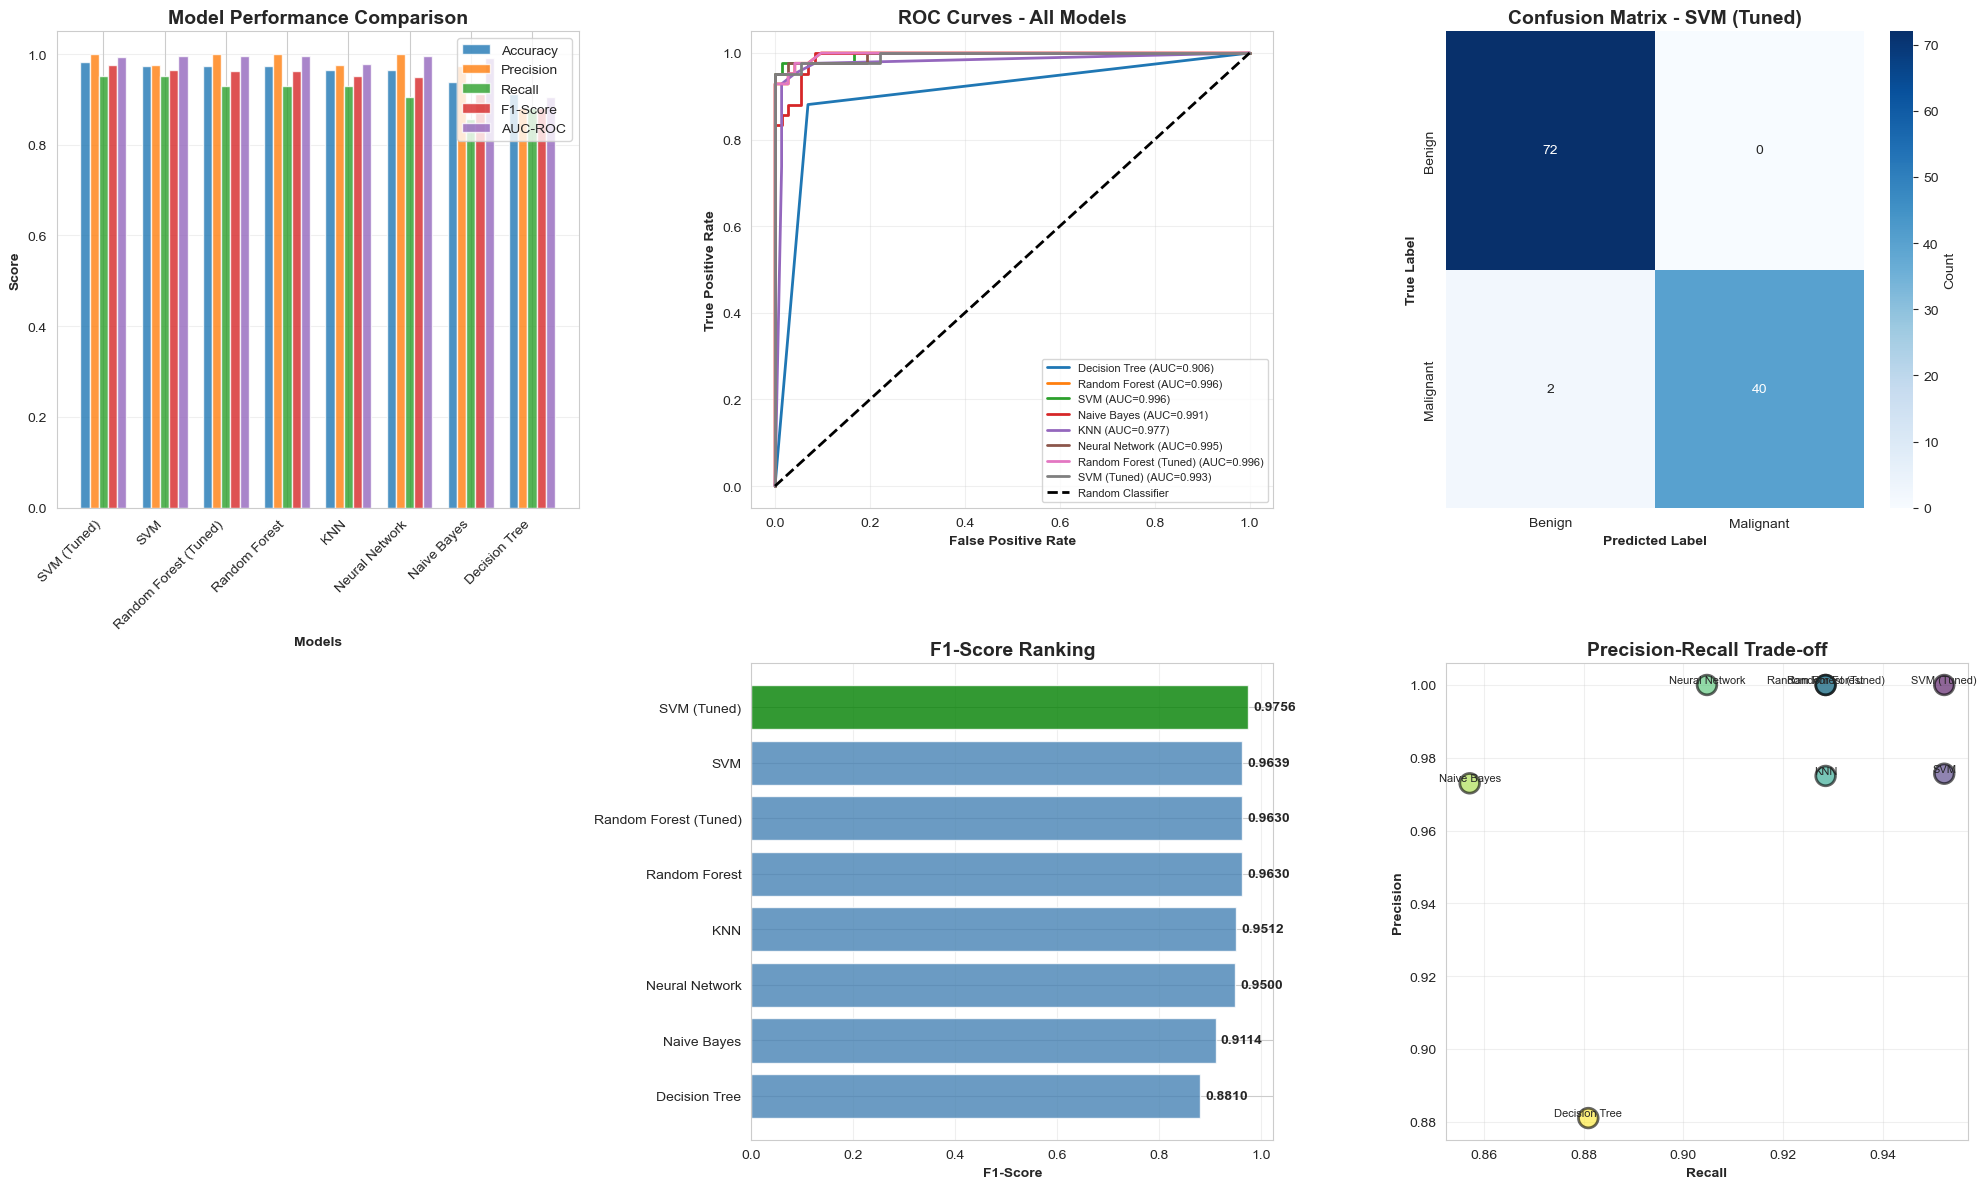

In [16]:
# ============================================================================
# 9. MODEL EVALUATION AND COMPARISON
# ============================================================================
print("\n" + "="*80)
print("MODEL EVALUATION AND COMPARISON")
print("="*80)

# Create results dataframe
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()],
    'AUC-ROC': [results[m]['auc_roc'] if results[m]['auc_roc'] else 0 for m in results.keys()]
})

results_df = results_df.sort_values('F1-Score', ascending=False)
print("\n[1] Performance Metrics for All Models:")
print(results_df.to_string(index=False))

# Find best model
best_model_name = results_df.iloc[0]['Model']
print(f"\n[2] Best Performing Model: {best_model_name}")
print(f"    F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")
print(f"    Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"    AUC-ROC: {results_df.iloc[0]['AUC-ROC']:.4f}")

# ============================================================================
# 10. VISUALIZATIONS
# ============================================================================
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))

# 1. Model Comparison - Bar Chart
ax1 = plt.subplot(2, 3, 1)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(results_df))
width = 0.15

for i, metric in enumerate(metrics):
    ax1.bar(x + i*width, results_df[metric], width, label=metric, alpha=0.8)

ax1.set_xlabel('Models', fontweight='bold')
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width * 2)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. ROC Curves
ax2 = plt.subplot(2, 3, 2)
for name, result in results.items():
    if result['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
        auc = result['auc_roc']
        ax2.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)

ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
ax2.set_xlabel('False Positive Rate', fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontweight='bold')
ax2.set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=8)
ax2.grid(alpha=0.3)

# 3. Confusion Matrix for Best Model
ax3 = plt.subplot(2, 3, 3)
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar_kws={'label': 'Count'})
ax3.set_xlabel('Predicted Label', fontweight='bold')
ax3.set_ylabel('True Label', fontweight='bold')
ax3.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
ax3.set_xticklabels(['Benign', 'Malignant'])
ax3.set_yticklabels(['Benign', 'Malignant'])

# 4. Feature Importance (for Random Forest)
if 'Random Forest' in best_model_name:
    ax4 = plt.subplot(2, 3, 4)
    feature_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': trained_models[best_model_name].feature_importances_
    }).sort_values('importance', ascending=False).head(15)
    
    ax4.barh(range(len(feature_imp)), feature_imp['importance'], color='steelblue', alpha=0.8)
    ax4.set_yticks(range(len(feature_imp)))
    ax4.set_yticklabels(feature_imp['feature'])
    ax4.set_xlabel('Importance', fontweight='bold')
    ax4.set_title(f'Top 15 Feature Importance - {best_model_name}', 
                  fontsize=14, fontweight='bold')
    ax4.invert_yaxis()
    ax4.grid(axis='x', alpha=0.3)

# 5. F1-Score Comparison
ax5 = plt.subplot(2, 3, 5)
colors = ['green' if i == 0 else 'steelblue' for i in range(len(results_df))]
ax5.barh(results_df['Model'], results_df['F1-Score'], color=colors, alpha=0.8)
ax5.set_xlabel('F1-Score', fontweight='bold')
ax5.set_title('F1-Score Ranking', fontsize=14, fontweight='bold')
ax5.invert_yaxis()
ax5.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(results_df['F1-Score']):
    ax5.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

# 6. Precision-Recall Trade-off
ax6 = plt.subplot(2, 3, 6)
precision_vals = results_df['Precision'].values
recall_vals = results_df['Recall'].values
ax6.scatter(recall_vals, precision_vals, s=200, alpha=0.6, c=range(len(results_df)), 
            cmap='viridis', edgecolors='black', linewidth=2)

for i, model in enumerate(results_df['Model']):
    ax6.annotate(model, (recall_vals[i], precision_vals[i]), 
                fontsize=8, ha='center', va='bottom')

ax6.set_xlabel('Recall', fontweight='bold')
ax6.set_ylabel('Precision', fontweight='bold')
ax6.set_title('Precision-Recall Trade-off', fontsize=14, fontweight='bold')
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_results.png', dpi=300, bbox_inches='tight')
print("\n[INFO] Model comparison visualizations saved as 'model_comparison_results.png'")
plt.show()


In [17]:
# ============================================================================
# 11. DETAILED CLASSIFICATION REPORT
# ============================================================================
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT - BEST MODEL")
print("="*80)

print(f"\nModel: {best_model_name}\n")
print(classification_report(y_test, results[best_model_name]['y_pred'], 
                          target_names=['Benign (0)', 'Malignant (1)']))

# ============================================================================
# 12. SAVE RESULTS
# ============================================================================
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Save results to CSV
results_df.to_csv('model_comparison_results.csv', index=False)
print("\n[1] Results saved to 'model_comparison_results.csv'")

# Save best model
import joblib
joblib.dump(trained_models[best_model_name], 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print(f"[2] Best model ({best_model_name}) saved as 'best_model.pkl'")
print("[3] Scaler saved as 'scaler.pkl'")

print("\n" + "="*80)
print("PROJECT EXECUTION COMPLETED SUCCESSFULLY!")
print("="*80)
print(f"\nBest Model: {best_model_name}")
print(f"Test Accuracy: {results[best_model_name]['accuracy']*100:.2f}%")
print(f"Test F1-Score: {results[best_model_name]['f1_score']:.4f}")
print(f"Test AUC-ROC: {results[best_model_name]['auc_roc']:.4f}")
print("\nAll visualizations and results have been saved.")
print("="*80)


DETAILED CLASSIFICATION REPORT - BEST MODEL

Model: SVM (Tuned)

               precision    recall  f1-score   support

   Benign (0)       0.97      1.00      0.99        72
Malignant (1)       1.00      0.95      0.98        42

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114


SAVING RESULTS

[1] Results saved to 'model_comparison_results.csv'
[2] Best model (SVM (Tuned)) saved as 'best_model.pkl'
[3] Scaler saved as 'scaler.pkl'

PROJECT EXECUTION COMPLETED SUCCESSFULLY!

Best Model: SVM (Tuned)
Test Accuracy: 98.25%
Test F1-Score: 0.9756
Test AUC-ROC: 0.9934

All visualizations and results have been saved.
